# Modélisation

## imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)
import joblib



## chargement & prétraitement 

In [7]:
df = pd.read_csv("C:\\Users\\khaye\\Downloads\\heart_disease_dataset\\heart.csv")



df = df.drop_duplicates()
print(f"Dataset après suppression : {df.shape}")
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}")   
print(f"Test  : {X_test.shape}")    

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)





Dataset après suppression : (302, 14)
Train : (241, 13)
Test  : (61, 13)


## entrainement des modèles 

In [19]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=11, random_state=42)
dt.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
print("Depth:", dt.get_depth())
print("Leaves:", dt.get_n_leaves())

print("✅ Modèles entraînés !")

Depth: 9
Leaves: 35
✅ Modèles entraînés !


## Évaluation & comparaison

In [15]:
models = {"Decision Tree": dt, "Random Forest": rf}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Modèle"   : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 3),
        "F1-Score" : round(f1_score(y_test, y_pred), 3),
        "Recall"   : round(recall_score(y_test, y_pred), 3),
        "AUC-ROC"  : round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

       Modèle  Accuracy  F1-Score  Recall  AUC-ROC
Decision Tree     0.721     0.738   0.727    0.833
Random Forest     0.754     0.776   0.788    0.859


## matrice de confusion

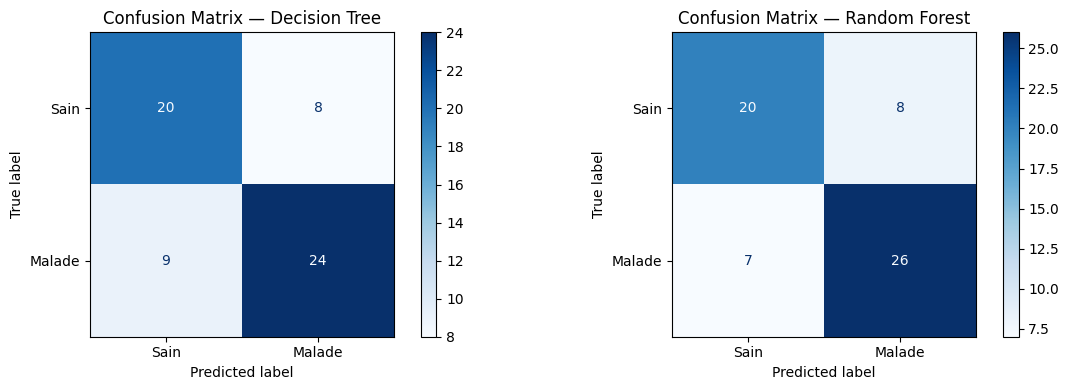

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Sain", "Malade"]).plot(ax=ax, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrices.png")
plt.show()